Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (200, 5)

First 5 Records:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Model Comparison
                     Model  Silhouette Score
0       K-Means Clustering            0.5539
1  Hierarchical Clustering            0.5530

Best Performing Model: K-Means Clustering


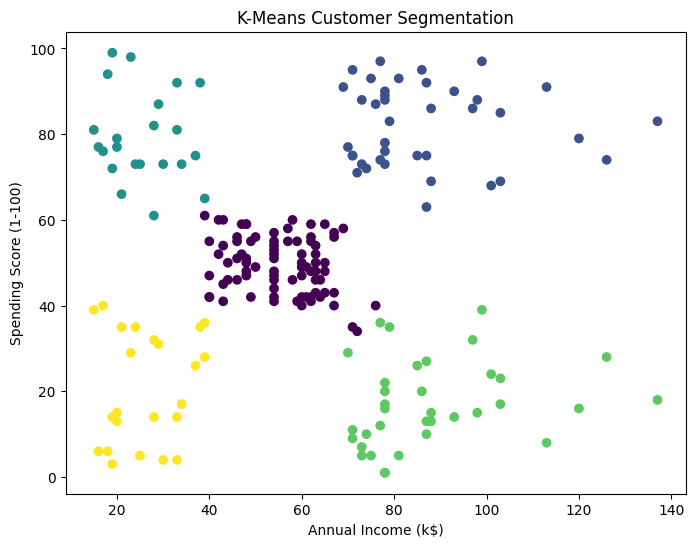

In [2]:
# ============================================================
# Task 3 - Model Optimization and Comparison
# Dataset: Mall Customer Segmentation
# Models: K-Means Clustering vs Hierarchical Clustering
# Evaluation Metric: Silhouette Score
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ============================================================
# Mount Google Drive
# ============================================================

drive.mount('/content/drive')

# ============================================================
# Load Dataset
# ============================================================

dataset_path = "/content/drive/MyDrive/internship_csv_files/Mall_Customers.csv"

df = pd.read_csv(dataset_path)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
print(df.head())

# ============================================================
# Feature Selection
# ============================================================

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# ============================================================
# Model 1: K-Means Clustering
# ============================================================

kmeans_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_model.fit_predict(X)

kmeans_silhouette = silhouette_score(
    X,
    kmeans_labels
)

# ============================================================
# Model 2: Hierarchical Clustering
# ============================================================

hierarchical_model = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical_model.fit_predict(X)

hierarchical_silhouette = silhouette_score(
    X,
    hierarchical_labels
)

# ============================================================
# Model Comparison Table
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "K-Means Clustering",
        "Hierarchical Clustering"
    ],
    "Silhouette Score": [
        round(kmeans_silhouette, 4),
        round(hierarchical_silhouette, 4)
    ]
})

print("\nModel Comparison")
print(comparison_df)

# ============================================================
# Best Performing Model
# ============================================================

best_model = comparison_df.loc[
    comparison_df["Silhouette Score"].idxmax(),
    "Model"
]

print(f"\nBest Performing Model: {best_model}")

# ============================================================
# Cluster Visualization - K-Means
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=kmeans_labels
)

plt.title("K-Means Customer Segmentation")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()